# Tool-result caching for AI agents

**Tool-result caching** reuses the output of a *read-only* tool call when the same tool, at the
same version, is called with the same canonical arguments by the same owner within a short time
window. The agent still reasons over the result; what it skips is the slow, metered round trip to
the tool provider.

The use case is a **research agent that helps a developer evaluate a library upgrade**. While it
plans, checks sources and writes its recommendation, its sub-steps call a web-search tool
([Tavily](https://docs.tavily.com/)) and often repeat exactly the same search. You will put a
shared cache in **Oracle AI Database** between the agent and that tool.

**What you will build and measure**

- A tool registry in which every tool declares whether it is read-only and how long its results stay fresh.
- Canonical argument handling, so the same call written two ways maps to one cache key.
- An Oracle table that stores tool arguments and results as native `JSON`, with an expiry time and the
  original collection time.
- `cached_call()`, which serves fresh hits, calls the tool on a miss, and never caches side effects.
- Real measurements: latency, Tavily calls and credits, Claude calls and estimated cost for every step.

**What you need:** an Anthropic API key, a Tavily API key, and a dedicated Oracle schema. The native `JSON`
data type the cache table uses arrived in Oracle Database 21c, so 21c or later works; this notebook was
run on Oracle AI Database Free. It runs end to end in under a minute and makes five Tavily searches and
one Claude call.

### Install the notebook packages

Use a **Python 3.12** kernel. Open this notebook from the `cache_techniques` folder so `requirements.txt` is available. Run the next cell before Part 1: **%pip** installs into the Python environment used by this notebook's active kernel.

`requirements.txt` installs **anthropic** for Claude, **sentence-transformers** for the open-source Hugging Face embedding model and reranker (it brings PyTorch and transformers), **oracledb** and **langchain-oracledb** for Oracle AI Database, **tavily-python** for web search, **pandas**, **pyarrow** and **huggingface_hub** for reading public Hugging Face datasets, and **numpy** and **matplotlib** for measurements and charts. It also installs JupyterLab, plus nbformat and nbclient, which `tests/run_notebooks.py` uses to run a notebook end to end.

After the first installation finishes, **restart the kernel**, then run the Parts in order. Installation needs internet access; it does not need your API keys.

In [1]:
# Install packages into this notebook's active Python kernel.
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


# Part 1 · How tool-result caching works

## 1.1 · The idea

An agent does not call a tool once. A planner decides it needs evidence and issues a search; a
verifier step re-checks the same source; a writer step looks it up again to quote it; a retry after a
failed step replays every call that came before. In a multi-agent setup several workers fan out over
the same task and ask the same question at nearly the same moment.

Each of those calls is a network round trip to a provider: hundreds of milliseconds to seconds of
latency, a metered charge (Tavily bills in *credits*), and pressure on rate limits. When the tool is
**read-only** and the arguments are identical, the answer it would return a few seconds later is, for
practical purposes, the answer it already returned.

A tool-result cache stores that answer under a key that captures the full identity of the call, and
hands it back while it is still fresh. Two things are worth being precise about:

- The cache reuses the **observation**, not the **decision**. The model still reads the result and
  reasons over it; only the call to the provider is skipped.
- This is different from caching the agent's final answer (an exact or semantic *response* cache). A
  tool cache sits lower in the stack, between the agent and its tools, so it helps even when every
  user question is different.

## 1.2 · The request flow

The diagram shows where the cache sits. The agent never talks to Tavily directly: every tool call goes
through a small **tool router**, which consults a registry describing each tool.

**Figure · Tool calls routed through an Oracle-backed tool cache**

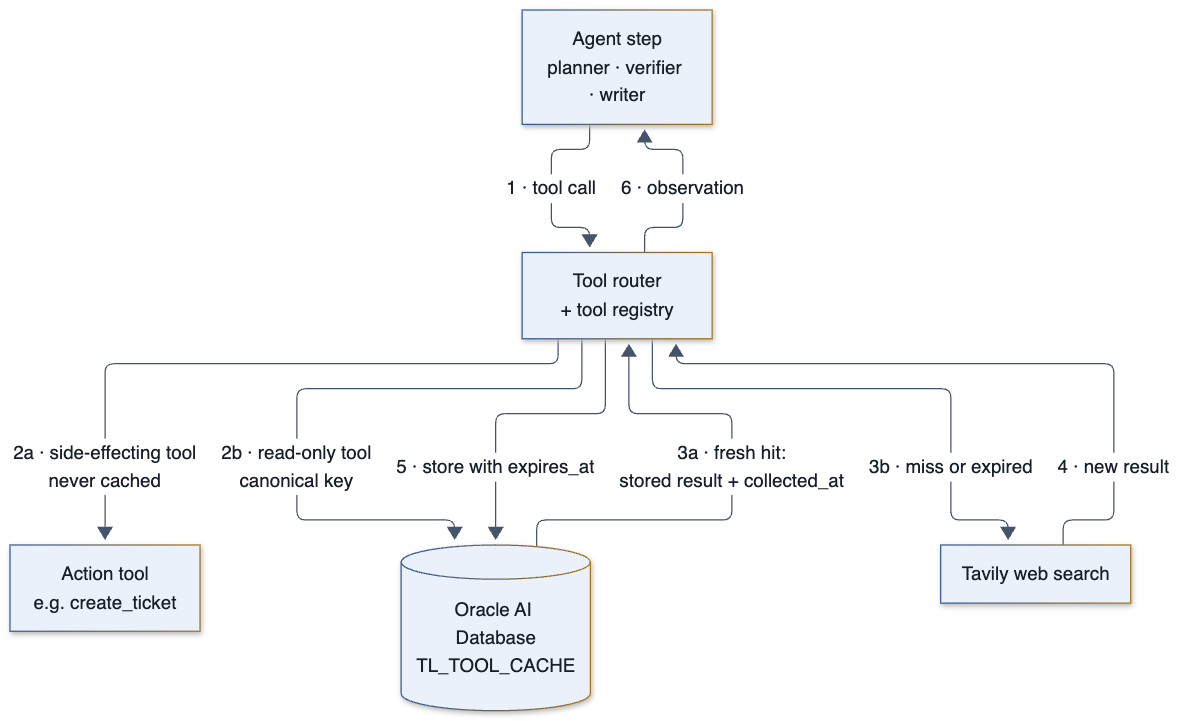

<details><summary>Mermaid source</summary>

```mermaid
flowchart TB
    Agent["Agent step<br/>planner · verifier · writer"] -->|1 · tool call| Router["Tool router<br/>+ tool registry"]
    Router -->|2a · side-effecting tool<br/>never cached| Action["Action tool<br/>e.g. create_ticket"]
    Router -->|2b · read-only tool<br/>canonical key| Cache[("Oracle AI Database<br/>TL_TOOL_CACHE")]
    Cache -->|3a · fresh hit:<br/>stored result + collected_at| Router
    Router -->|3b · miss or expired| Tavily["Tavily web search"]
    Tavily -->|4 · new result| Router
    Router -->|5 · store with expires_at| Cache
    Router -->|6 · observation| Agent
```

</details>

Step by step:

1. **Tool call.** An agent step asks for `web_search(query=...)`, exactly as it would without a cache.
2. **Route by tool type.** The router looks the tool up in the registry.
   - **2a.** A tool with side effects (create a ticket, send an email, book, pay) is executed directly.
     Its result is never stored and never replayed.
   - **2b.** A read-only tool gets its arguments canonicalised, and the router builds a cache key from
     the tool name, tool version, owner and canonical arguments. It looks that key up in Oracle.
3. **Hit or miss.**
   - **3a.** If a row exists and `expires_at` is still in the future, the stored result comes back,
     together with the time it was **originally collected**. No provider call is made.
   - **3b.** Otherwise (no row, or the row expired) the router calls Tavily.
4. **New result.** Tavily returns fresh results; the router stamps them with `collected_at`.
5. **Store.** The router writes the result with `expires_at = now + TTL` for that tool. Empty results
   and errors are not stored.
6. **Observation.** The agent receives the result either way and continues reasoning.

The cache is a table in Oracle rather than a Python dictionary because a real agent runs as several
workers (or several sub-agents in different processes). A shared table lets one worker's search serve
the others, and survives a restart.

## 1.3 · What makes two calls the same

The cache key decides what counts as a repeat. Too loose and the agent receives a result for a
different question; too strict and identical calls miss. The key is a SHA-256 hash of four parts:

| Part | Why it is in the key |
|---|---|
| **Tool name** | `web_search` and a news search can take the same arguments and return different things. |
| **Tool version** | When you change the provider, its parameters or the shape of the stored result, bump the version so old rows can no longer match. |
| **Owner** | A team, tenant or user. Owners can have different permissions, API accounts or domain filters; one owner's results must never leak to another. |
| **Canonical arguments** | The full set of arguments that affect the result, in a single normal form. |

**Canonicalising arguments** turns the many ways of writing one call into one normal form:

- **Fill defaults.** `web_search(query=q)` and `web_search(query=q, max_results=3)` are the same call if
  the default is 3, so defaults are written into the arguments before hashing.
- **Drop unset values.** `None` means "not provided", so it is removed instead of hashed.
- **Sort keys.** Keyword order never changes the result, so the arguments are serialised with sorted keys.
- **Normalise text only where meaning is unchanged.** Collapsing repeated spaces and trimming a search
  query is safe. Lower-casing it is *not* automatically safe (`Go` the language versus `go` the verb),
  so this notebook leaves case alone. Each tool declares which arguments are free text.

Everything that changes the result must stay in the key: `max_results=5` is a different call from
`max_results=3`, even though the query is the same.

## 1.4 · Freshness, expiry and invalidation

Web search results are **live data**: pages change, new releases ship, rankings move. A tool cache
therefore uses short, per-tool lifetimes instead of one global setting:

- **TTL per tool.** A documentation search can stay fresh for minutes; a "latest release" or status
  check for seconds; a price or availability lookup is often not worth caching at all. The registry
  stores `ttl_seconds` next to each tool.
- **Expiry on read.** Each row has `expires_at`. A lookup only accepts rows where `expires_at` is in the
  future, so an expired row behaves exactly like a miss and is overwritten by the next fresh call.
- **Keep the original collection time.** A hit returns *old evidence*. The stored `collected_at` is
  returned unchanged, so the agent (and its final answer) can say when the evidence was gathered, not
  when it was read from the cache.
- **Invalidate by version.** Changing what a tool does means bumping its version string. New keys stop
  matching old rows immediately; the old rows simply expire.
- **Do not cache failures or empty results.** A timeout or an empty result list is usually transient.
  Storing it would make the failure sticky for the whole TTL.

## 1.5 · When it helps and when it hurts

**It helps** when the same read-only call repeats inside a short window: multi-step plans, verifier
loops, retries, and parallel workers. Each hit removes a provider round trip, a metered charge and a
request against the rate limit. It also makes a run more reproducible, because every step of one task
sees the same evidence.

**It hurts** when the window is wrong or the key is incomplete:

- **Stale evidence.** A TTL that is too long serves results that no longer reflect the web.
- **Leaks across owners.** A key without the owner can hand one tenant's filtered results to another.
- **Missing arguments.** A key that ignores `max_results` or a domain filter returns the wrong result set.

And there is one hard rule: **never cache a tool with side effects.** If `create_ticket` were cached,
the second call would return the *first* ticket's ID while no new ticket was created; a cached
`send_email` would report success for an email that was never sent. The agent would believe an action
happened when it did not. Retrying an action safely is a job for **idempotency keys** on the action
itself, not for a cache.

### Takeaways

- Cache the **observation** of a read-only tool, never the execution of an action.
- The key is tool + version + owner + **canonical** arguments; everything that changes the result belongs in it.
- Use a short TTL per tool, check it on read, and keep the original `collected_at` on every hit.
- Do not store errors or empty results; invalidate by bumping the tool version.

# Part 2 · The use case: a research agent evaluating a library upgrade

## 2.1 · The scenario

A developer asks the agent: *"Should our agent adopt `OracleSemanticCache` from `langchain-oracledb`,
and what does it need?"* The agent breaks the question into steps:

1. **Plan:** search for the component's documentation and requirements.
2. **Gather:** read the top results, then search again to confirm details.
3. **Verify:** re-check the sources it intends to cite.
4. **Write:** produce a short recommendation with citations, and open a ticket for the follow-up work.

Steps 1–3 issue the **same web search** several times, because each step is written to be
self-contained and does not know what earlier steps already fetched. Without a cache, every one of
those calls goes to Tavily. Step 4 includes an **action** (creating a ticket) that must happen exactly
when the agent asks for it, every time.

## 2.2 · Where the cache sits in the agent's memory

It helps to place the tool cache among the agent's kinds of memory:

- **Working memory** is what the current task has in context: the question, the plan, and the
  observations gathered so far. Tool results land here.
- **Episodic memory** is the record of what happened: which tool was called, with what arguments, what
  came back, from which URL, and *when*. This is the **memory of record** for the run.
- **Semantic memory** holds distilled, longer-lived facts ("the component stores vectors in Oracle").
  Facts promoted from tool results must keep their provenance, or stale evidence turns into permanent
  belief.
- **Procedural memory** is how the agent works: which tools exist and how to use them. The tool
  registry, with its read-only flags and TTLs, belongs here.

The tool cache is none of these. It is a short-lived, shared store of **observations with provenance**
that saves the agent from re-fetching what it has just seen. A cache hit is *old* evidence, not *new*
evidence: the episode log should record that the result came from the cache and when it was
originally collected. And an action is never a memory to replay: the episode log records that a
ticket was created; the cache never pretends to create it again.

**Figure · The research agent with a shared tool cache and its memory**

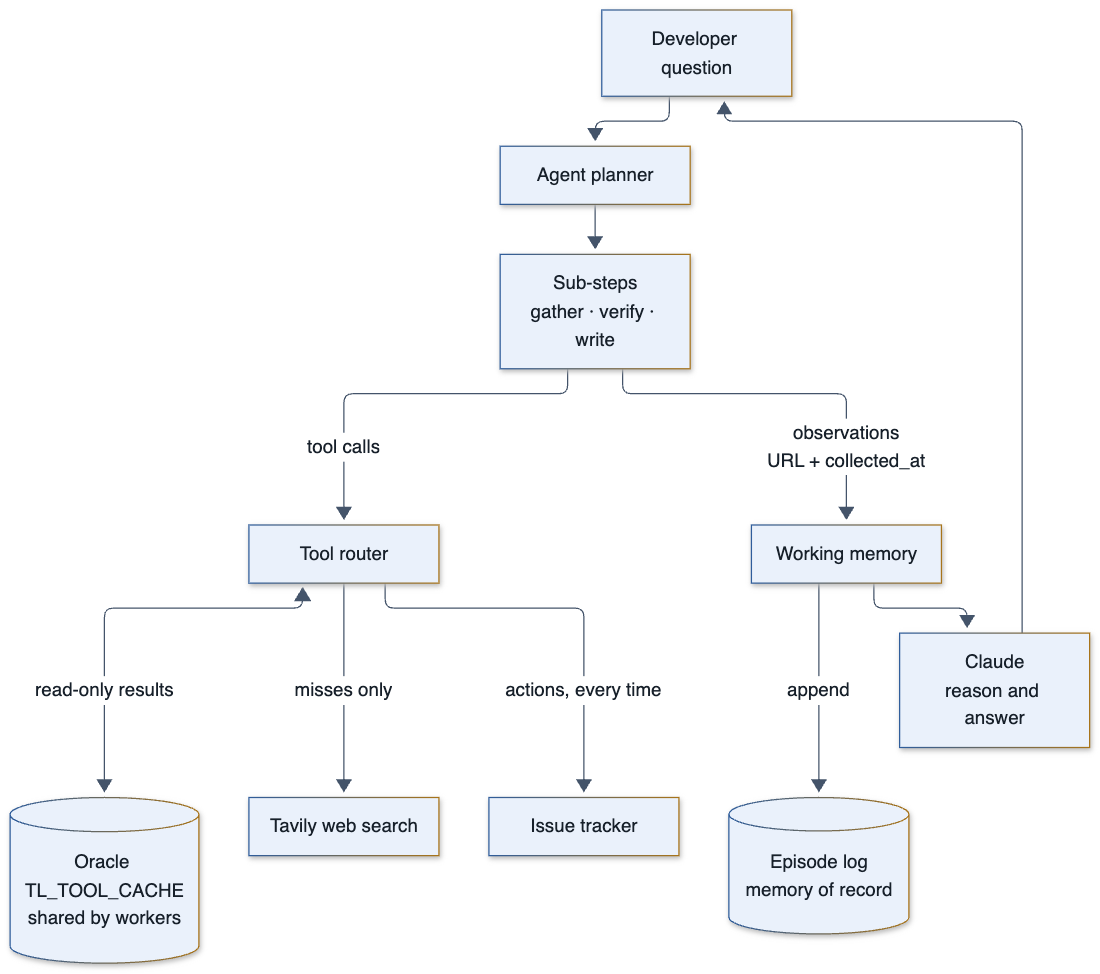

<details><summary>Mermaid source</summary>

```mermaid
flowchart TB
    Dev["Developer question"] --> Planner["Agent planner"]
    Planner --> Steps["Sub-steps<br/>gather · verify · write"]
    Steps -->|tool calls| Router["Tool router"]
    Router <-->|read-only results| Cache[("Oracle TL_TOOL_CACHE<br/>shared by workers")]
    Router -->|misses only| Tavily["Tavily web search"]
    Router -->|actions, every time| Tracker["Issue tracker"]
    Steps -->|observations<br/>URL + collected_at| WM["Working memory"]
    WM --> Claude["Claude<br/>reason and answer"]
    WM -->|append| Log[("Episode log<br/>memory of record")]
    Claude --> Dev
```

</details>

### Takeaways

- Agents repeat identical tool calls because their steps are self-contained; the cache absorbs that repetition.
- Tool results are observations in working memory; their provenance (URL, `collected_at`) must travel with them.
- The cache is not the memory of record: the episode log is.
- Actions are recorded in memory, never replayed from a cache.

# Part 3 · Set up

## 3.1 · Imports and clients

The notebook uses the raw provider SDKs: `anthropic` for Claude, `tavily` for web search and
`oracledb` (thin mode, no Oracle client install) for the database. `pandas` displays the measurements.

In [2]:
import hashlib
import json
import os
import time
import uuid
from datetime import datetime, timezone
from getpass import getpass

import oracledb
import pandas as pd
from anthropic import Anthropic
from IPython.display import display
from tavily import TavilyClient

### Read private keys safely

`secret()` asks for a key with `getpass`, so the value is never echoed into the notebook
or saved with its outputs. Automated runs can set `NOTEBOOK_USE_ENV_KEYS=1` to read the
same name from an environment variable instead. An empty value stops the notebook early
with a clear error rather than failing later inside a provider call.

In [3]:
def secret(name):
    """Return a private key from a hidden prompt, or from the environment in automated runs."""
    if os.getenv("NOTEBOOK_USE_ENV_KEYS") == "1":
        value = os.getenv(name, "")
    else:
        value = getpass(f"Enter {name}: ")
    if not value.strip():
        raise ValueError(f"{name} is required.")
    return value.strip()

### Price every Claude call from reported usage

Every response from the Anthropic API reports how many tokens it processed. The prices below
are the published list prices for Claude Opus 5.5 (USD per million tokens, checked on
2026-10-03). Each counter is priced separately:

- `input`: ordinary prompt tokens.
- `cache_write`: prompt tokens written to Anthropic's prompt cache (1.25× input).
- `cache_read`: prompt tokens read back from that cache (0.05× input on Opus 5.5).
- `output`: generated tokens, the most expensive counter.

`LLM_CALLS` is a ledger: one row per real request, so every cost in this notebook can be
traced back to an actual API response. These are list-price estimates, not an invoice.

In [4]:
MODEL = "claude-opus-5-5"
PRICE = {"input": 4.00, "cache_write": 5.00, "cache_read": 0.20, "output": 20.00}
LLM_CALLS = []


def llm_cost(usage):
    """Price one response from the token counters the API returned."""
    tokens = {
        "input": usage.input_tokens,
        "cache_write": usage.cache_creation_input_tokens or 0,
        "cache_read": usage.cache_read_input_tokens or 0,
        "output": usage.output_tokens,
    }
    return tokens, sum(tokens[k] * PRICE[k] for k in tokens) / 1_000_000

### One function for every model call

`ask_claude()` sends a single request with the raw Anthropic SDK. `system` is either a plain
string or a list of content blocks (the list form is what lets a block carry a prompt-cache
breakpoint). `effort="low"` asks the model for a direct answer, which keeps latency and
output tokens down. The function records latency, the four token counters and the estimated
cost in `LLM_CALLS`, then returns only the visible text.

In [5]:
def ask_claude(system, user, max_tokens=1024):
    """Send one request, record latency, tokens and cost, and return the answer text."""
    started = time.perf_counter()
    response = claude.messages.create(
        model=MODEL,
        max_tokens=max_tokens,
        system=system,
        messages=[{"role": "user", "content": user}],
        output_config={"effort": "low"},
    )
    tokens, usd = llm_cost(response.usage)
    seconds = time.perf_counter() - started
    LLM_CALLS.append({"seconds": seconds, **tokens, "usd": usd})
    return "".join(b.text for b in response.content if b.type == "text")

Create the client. The key is read with `secret()`; the client object keeps it in memory
only. A timeout and two retries keep a slow network from hanging the notebook.

In [6]:
claude = Anthropic(api_key=secret("ANTHROPIC_API_KEY"), timeout=120, max_retries=2)

### Connect to Oracle AI Database

The cache tables live in a **dedicated application schema**. `oracle_connection()` reads
`ORACLE_USER`, `ORACLE_PASSWORD` and `ORACLE_DSN` from the environment and prompts for any
that are missing (the password prompt is hidden). It refuses `SYS` and `SYSTEM`: an
application cache should never run with administrator privileges. The schema needs
`CREATE TABLE` and a tablespace quota; vector features need Oracle AI Database 23ai or later.

In [7]:
def oracle_connection():
    """Connect to a dedicated schema; administrator accounts are refused."""
    user = os.getenv("ORACLE_USER") or input("Oracle user: ").strip()
    password = os.getenv("ORACLE_PASSWORD") or getpass("Oracle password: ")
    dsn = os.getenv("ORACLE_DSN") or input("Oracle DSN (host:port/service): ").strip()
    if user.lower() in {"sys", "system"}:
        raise ValueError("Use a dedicated application schema.")
    return oracledb.connect(user=user, password=password, dsn=dsn)


conn = oracle_connection()
print("Connected to Oracle", conn.version)

Connected to Oracle 23.26.2.0.0


`create_if_missing()` makes the DDL in this notebook safe to re-run. Oracle raises
`ORA-00955` when an object name already exists; only that error is ignored. Anything else,
such as a missing privilege or an exhausted vector memory pool, is raised so you can see it.

In [8]:
def create_if_missing(sql):
    """Run DDL, ignoring only 'name is already used by an existing object'."""
    with conn.cursor() as cursor:
        try:
            cursor.execute(sql)
        except oracledb.DatabaseError as error:
            if error.args[0].code != 955:
                raise

### The Tavily client and its ledger

Tavily bills searches in **credits**; a basic search costs one credit. With `include_usage=True` the
response reports the credits it consumed, so cost is computed from what Tavily says, not assumed.
`TAVILY_USD_PER_CREDIT` is the pay-as-you-go list price (USD 0.008), configurable through the
environment because plans differ. `TOOL_CALLS` is the ledger of real Tavily requests: one row per call,
with latency, credits and estimated cost. A cache hit adds nothing to it.

In [9]:
TAVILY_USD_PER_CREDIT = float(os.getenv("TAVILY_USD_PER_CREDIT", "0.008"))
TOOL_CALLS = []
tavily = TavilyClient(api_key=secret("TAVILY_API_KEY"))

### The task and its owner

`RUN_ID` identifies this run; every cache row it writes carries it, so the cleanup cell at the end can
remove exactly those rows. `OWNER` is the team the agent works for. Including the run ID in the owner
also means a re-run of this notebook starts with an empty cache instead of hitting rows from an earlier
run.

`QUERY` is the search the agent's steps keep issuing. Set the `TOOL_CACHE_QUERY` environment variable to
try your own search without editing the notebook.

In [10]:
RUN_ID = uuid.uuid4().hex
OWNER = f"platform-team:{RUN_ID[:8]}"
QUESTION = "Should our agent adopt OracleSemanticCache from langchain-oracledb, and what does it need?"
QUERY = os.getenv(
    "TOOL_CACHE_QUERY",
    "langchain-oracledb OracleSemanticCache semantic cache for LLM responses",
)
print("owner:", OWNER, "| query:", QUERY)

owner: platform-team:6be71cb8 | query: langchain-oracledb OracleSemanticCache semantic cache for LLM responses


# Part 4 · Build the tool cache

## 4.1 · The cache table

One table holds every cached tool result, for every tool and owner:

- `cache_key` is the SHA-256 identity of the call and the **primary key**, so there is at most one row
  per call identity. Two workers that miss at the same moment both try to insert the same key: neither
  sees the other's uncommitted row, so the second insert fails with `ORA-00001` once the first commits.
  `merge_once()` treats that error as success, because an identical call's result is now stored.
- `tool`, `tool_version` and `owner` are stored in clear so you can inspect and purge by them.
- `arguments` and `result` use Oracle's native **`JSON`** type. It stores documents in a binary format,
  validates them on insert, and lets SQL read fields with dot notation (you will query
  `t.arguments.max_results` later).
- `collected_at` is when the provider produced the result; `expires_at` is when it stops being served.
- `run_id` scopes the rows to this notebook run for cleanup.

In [11]:
create_if_missing("""
    CREATE TABLE TL_TOOL_CACHE (
        cache_key    VARCHAR2(64) PRIMARY KEY,
        tool         VARCHAR2(100) NOT NULL,
        tool_version VARCHAR2(40) NOT NULL,
        owner        VARCHAR2(200) NOT NULL,
        arguments    JSON NOT NULL,
        result       JSON NOT NULL,
        collected_at TIMESTAMP WITH TIME ZONE NOT NULL,
        expires_at   TIMESTAMP WITH TIME ZONE NOT NULL,
        run_id       VARCHAR2(32) NOT NULL
    )
""")

## 4.2 · The tools

### The raw Tavily call

`tavily_search()` is the only place that talks to Tavily. It forwards the arguments, asks Tavily to
report usage, and appends one row to `TOOL_CALLS` with the latency, the credits Tavily reported and the
estimated cost. If Tavily does not report credits, the cost is recorded as unknown (`None`) rather
than guessed.

In [12]:
def tavily_search(**arguments):
    """Call Tavily once and record its latency and reported credits in TOOL_CALLS."""
    started = time.perf_counter()
    response = tavily.search(**arguments, include_usage=True, timeout=60)
    credits = (response.get("usage") or {}).get("credits")
    usd = None if credits is None else credits * TAVILY_USD_PER_CREDIT
    TOOL_CALLS.append(
        {"seconds": time.perf_counter() - started, "credits": credits, "usd": usd}
    )
    return response

### The read-only search tool

`web_search()` is the tool the agent sees. It keeps only the fields the agent reads (URL, title and the
first 500 characters of the extracted content). Trimming matters for a cache: smaller rows are cheaper
to store and to send back to the model. It stamps the result with `collected_at`, in UTC and ISO 8601
format, at the moment the provider answered. That timestamp is part of the result, so it is stored
with it and returned unchanged on every hit.

In [13]:
def web_search(query, max_results, search_depth, topic):
    """Read-only tool: search the web; return trimmed results and their collection time."""
    response = tavily_search(
        query=query, max_results=max_results, search_depth=search_depth, topic=topic
    )
    results = [
        {
            "url": r["url"],
            "title": r.get("title"),
            "content": (r.get("content") or "")[:500],
        }
        for r in response.get("results", [])
    ]
    collected_at = datetime.now(timezone.utc).isoformat(timespec="seconds")
    return {"results": results, "collected_at": collected_at}

### A side-effecting tool (local stub)

`create_ticket()` stands in for an issue tracker. It is a **local stub**: it only appends to the Python
list `TICKETS` and has no external effect. What matters is its contract: every call must create a new
ticket with a new ID. You will use it to prove that the router never caches actions.

In [14]:
TICKETS = []  # local stand-in for an issue tracker; nothing leaves this notebook


def create_ticket(title, body):
    """Side-effecting tool (local stub): every call creates a new ticket."""
    created = datetime.now(timezone.utc).isoformat(timespec="seconds")
    ticket = {
        "ticket_id": f"LOCAL-{len(TICKETS) + 1}",
        "title": title,
        "created_at": created,
    }
    TICKETS.append({**ticket, "body": body})
    return ticket

## 4.3 · The tool registry

The registry is the agent's procedural knowledge about its tools. `tool_spec()` describes one tool:

- `fn`: the function to call.
- `version`: part of the cache key; bump it whenever the tool's behaviour or result shape changes.
- `read_only`: only read-only tools are ever cached.
- `ttl_seconds`: how long a result stays fresh.
- `defaults`: argument values filled in before hashing, so omitted defaults still match.
- `text_args`: free-text arguments whose whitespace may be normalised.

In [15]:
def tool_spec(fn, version, read_only, ttl_seconds, defaults=None, text_args=()):
    """Describe one tool: what it runs, its version, and whether and how long it is cached."""
    return {
        "fn": fn,
        "version": version,
        "read_only": read_only,
        "ttl_seconds": ttl_seconds,
        "defaults": defaults or {},
        "text_args": list(text_args),
    }

Three tools are registered:

- `web_search`: a general documentation search, fresh for **10 minutes**.
- `release_check`: the same Tavily search used for a fast-changing question ("what is the latest
  release?"). It has its own name and version, and a deliberately tiny TTL of **5 seconds** so you can
  watch a row expire. In production this would be minutes, not seconds.
- `create_ticket`: an action, `read_only=False`, so it is never cached.

In [16]:
SEARCH_DEFAULTS = {"max_results": 3, "search_depth": "basic", "topic": "general"}
TOOLS = {
    "web_search": tool_spec(
        web_search, "tavily-search-v1", True, 600, SEARCH_DEFAULTS, ["query"]
    ),
    "release_check": tool_spec(
        web_search, "tavily-release-v1", True, 5, SEARCH_DEFAULTS, ["query"]
    ),
    "create_ticket": tool_spec(create_ticket, "local-stub-v1", False, 0),
}
print({name: (spec["read_only"], spec["ttl_seconds"]) for name, spec in TOOLS.items()})

{'web_search': (True, 600), 'release_check': (True, 5), 'create_ticket': (False, 0)}


## 4.4 · Canonical arguments

`canonical_args()` produces the normal form of a call's arguments:

1. Start from the tool's defaults, then overlay the arguments that were actually provided, skipping
   `None` (meaning "not provided").
2. For each free-text argument, collapse runs of whitespace into single spaces and trim the ends.
   Nothing else about the text changes.
3. Return the arguments sorted by name.

The same normal form is used both to call the tool and to build the key, so what is cached is exactly
what was asked.

In [17]:
def canonical_args(tool, arguments):
    """Fill defaults, drop unset values, tidy whitespace in free text, and sort the keys."""
    spec = TOOLS[tool]
    merged = {
        **spec["defaults"],
        **{k: v for k, v in arguments.items() if v is not None},
    }
    for name in spec["text_args"]:
        merged[name] = " ".join(str(merged[name]).split())
    return dict(sorted(merged.items()))

## 4.5 · The cache key

`tool_key()` hashes the full identity of a call: tool name, tool version, owner and canonical
arguments. `json.dumps(..., sort_keys=True, separators=(",", ":"))` produces one exact byte string for a
given identity (no spacing or key-order differences), and SHA-256 turns it into a fixed 64-character
key. The hash is an identifier, not a secret: anyone with the same inputs gets the same key, which is
exactly what lets separate workers share results.

In [18]:
def tool_key(tool, arguments, owner):
    """Hash a call's identity: tool, version, owner and canonical arguments."""
    identity = {
        "tool": tool,
        "version": TOOLS[tool]["version"],
        "owner": owner,
        "arguments": canonical_args(tool, arguments),
    }
    text = json.dumps(identity, sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(text.encode()).hexdigest()

## 4.6 · Read a fresh result

`cache_get()` looks up one key and accepts the row only if `expires_at > SYSTIMESTAMP`, so an expired
row is indistinguishable from a missing one. The lookup is a primary-key read: a single index probe,
regardless of how many rows the table holds. python-oracledb returns the `JSON` column as an ordinary
Python `dict`, so no parsing is needed.

In [19]:
def cache_get(key):
    """Return the stored result for a key if it has not expired, otherwise None."""
    with conn.cursor() as cursor:
        cursor.execute(
            "SELECT result FROM TL_TOOL_CACHE"
            " WHERE cache_key = :cache_key AND expires_at > SYSTIMESTAMP",
            cache_key=key,
        )
        row = cursor.fetchone()
    return row[0] if row else None

## 4.7 · Store a result

The write is a `MERGE` (an upsert) rather than an `INSERT`, because the key may already exist as an
**expired** row from an earlier call. When it does, the row is refreshed in place with the new result,
collection time and expiry; when it does not, a new row is inserted.

- `TO_UTC_TIMESTAMP_TZ(:collected_at)` converts the ISO 8601 text produced by `web_search()` into a
  `TIMESTAMP WITH TIME ZONE`, so the column holds the provider's collection time, not the write time.
- `SYSTIMESTAMP + NUMTODSINTERVAL(:ttl, 'SECOND')` computes the expiry on the database clock, the same
  clock `cache_get()` compares against.

In [20]:
UPSERT = """
MERGE INTO TL_TOOL_CACHE t
USING (SELECT :cache_key AS cache_key FROM dual) s ON (t.cache_key = s.cache_key)
WHEN MATCHED THEN UPDATE SET
    t.result = :result, t.collected_at = TO_UTC_TIMESTAMP_TZ(:collected_at),
    t.expires_at = SYSTIMESTAMP + NUMTODSINTERVAL(:ttl, 'SECOND')
WHEN NOT MATCHED THEN INSERT
    (cache_key, tool, tool_version, owner, arguments, result, collected_at, expires_at, run_id)
VALUES (:cache_key, :tool, :tool_version, :owner, :arguments, :result,
    TO_UTC_TIMESTAMP_TZ(:collected_at), SYSTIMESTAMP + NUMTODSINTERVAL(:ttl, 'SECOND'), :run_id)
"""

`upsert_binds()` gathers the values the statement needs, by bind name: the call's identity (key, tool,
version, owner), the two JSON documents, the original collection time, the tool's TTL from the registry,
and the `run_id` tag used for cleanup.

In [21]:
def upsert_binds(key, tool, arguments, result, owner):
    """Collect the values for UPSERT: identity, JSON documents, timing and run tag."""
    return {
        "cache_key": key,
        "tool": tool,
        "tool_version": TOOLS[tool]["version"],
        "owner": owner,
        "arguments": arguments,
        "result": result,
        "collected_at": result["collected_at"],
        "ttl": TOOLS[tool]["ttl_seconds"],
        "run_id": RUN_ID,
    }

`merge_once()` runs one upsert and absorbs exactly one error: `ORA-00001` (error code 1), the unique-key
violation a worker gets when another worker inserted the same key first. The row it wanted to store
already exists, so that is success. Any other database error is raised.

In [22]:
def merge_once(cursor, sql, binds):
    """Run an upsert MERGE; if another worker inserted the same key first, its row stands."""
    try:
        cursor.execute(sql, binds)
    except oracledb.IntegrityError as error:
        if error.args[0].code != 1:  # anything other than ORA-00001 is a real failure
            raise

`cache_put()` runs the statement. `setinputsizes(... DB_TYPE_JSON)` tells python-oracledb to send the
`arguments` and `result` dictionaries as native Oracle JSON instead of text. The commit makes the row
visible to every other worker. The statement runs through `merge_once()`, so a concurrent first write by
another worker is not an error.

In [23]:
def cache_put(key, tool, arguments, result, owner):
    """Store a fresh result with the tool's TTL and the original collection time."""
    with conn.cursor() as cursor:
        cursor.setinputsizes(
            arguments=oracledb.DB_TYPE_JSON, result=oracledb.DB_TYPE_JSON
        )
        merge_once(cursor, UPSERT, upsert_binds(key, tool, arguments, result, owner))
    conn.commit()

## 4.8 · The cached tool call

`cached_call()` is the tool router from the diagram. Every tool call in the agent goes through it:

1. Canonicalise the arguments.
2. **Actions bypass the cache.** If the tool is not read-only, run it and return
   `cache="bypass"`. Nothing is looked up and nothing is stored.
3. Build the key and look it up. A fresh row is returned with `cache="hit"`, including its original
   `collected_at`.
4. On a miss, call the tool. Store the result only if it contains results: an empty result set is not
   worth remembering, and an exception (a timeout, an auth error) propagates before anything is stored.

The returned dictionary always says which path was taken, so the agent and the measurements can record it.

In [24]:
def cached_call(tool, owner=None, **arguments):
    """Route a tool call: bypass actions, serve fresh hits, otherwise call and store."""
    spec, owner = TOOLS[tool], owner or OWNER
    arguments = canonical_args(tool, arguments)
    if not spec["read_only"]:
        return {"result": spec["fn"](**arguments), "cache": "bypass"}
    key = tool_key(tool, arguments, owner)
    found = cache_get(key)
    if found is not None:
        return {"result": found, "cache": "hit", "key": key}
    result = spec["fn"](**arguments)
    if result.get("results"):  # errors raise above; empty results are not stored
        cache_put(key, tool, arguments, result, owner)
    return {"result": result, "cache": "miss", "key": key}

## 4.9 · Measure each step

`usage_since()` summarises the paid work between two positions in the ledgers: how many Tavily calls
were made, the credits they reported, how many Claude calls, and the total estimated cost. If any call
had an unknown cost, the total is `None` rather than an undercount.

In [25]:
def usage_since(tools_before, llm_before):
    """Summarise the Tavily and Claude calls made since the given ledger positions."""
    tools, llms = TOOL_CALLS[tools_before:], LLM_CALLS[llm_before:]
    costs = [t["usd"] for t in tools] + [c["usd"] for c in llms]
    return {
        "tool_calls": len(tools),
        "tavily_credits": sum(t["credits"] or 0 for t in tools),
        "llm_calls": len(llms),
        "estimated_usd": None if None in costs else round(sum(costs), 6),
    }

`measure()` runs one agent step, times it with a monotonic clock, and appends one row to
`MEASUREMENTS`: the step name, its latency, which cache path it took (`hit`, `miss`, `bypass`, or
`none` for an uncached call) and the paid work from `usage_since()`.

In [26]:
MEASUREMENTS = []


def measure(step, run):
    """Run one agent step and record its latency, cache outcome and paid work."""
    marks = len(TOOL_CALLS), len(LLM_CALLS)
    started = time.perf_counter()
    outcome = run()
    seconds = round(time.perf_counter() - started, 3)
    cache = outcome.get("cache", "none") if isinstance(outcome, dict) else "none"
    row = {
        "step": step,
        "seconds": seconds,
        "cache": cache,
        "cache_hit": cache == "hit",
    }
    MEASUREMENTS.append({**row, **usage_since(*marks)})
    return outcome

# Part 5 · Run the agent with and without the cache

## 5.1 · Baseline: search without a cache

First, the agent's search as it would run with no cache: a direct call to `web_search()` with the
default arguments. This is the cost every repeated search pays when nothing is cached.

**What to watch:** the result titles and URLs, the `collected_at` time, and (in the final table) one
Tavily call with its credit and a latency of hundreds of milliseconds to a few seconds.

In [27]:
baseline = measure(
    "baseline: direct search", lambda: web_search(QUERY, **SEARCH_DEFAULTS)
)
for item in baseline["results"]:
    print("-", item["title"], "→", item["url"])
print("collected_at:", baseline["collected_at"])

- LangChain Python Integration → https://docs.oracle.com/en/database/oracle/oracle-database/26/aintg/langchain-oracledb-integration-guide/langchain-python.html
- A tour of LangChain Oracle ingestion and retrieval | developers → https://blogs.oracle.com/developers/a-tour-of-langchain-oracle-ingestion-and-retrieval
- A Semantic Cache using LangChain → https://www.youtube.com/watch?v=LRswXEc5chE
collected_at: 2026-10-03T17:21:10+00:00


## 5.2 · Cold cache: the first call misses

The planner step makes the same search through `cached_call()`. The cache is empty for this owner,
so this is a **miss**: the router calls Tavily and stores the result.

**What to watch:** `cache` is `miss`, and the result has its own new `collected_at`.

In [28]:
cold = measure("cold: miss, then store", lambda: cached_call("web_search", query=QUERY))
print(
    cold["cache"],
    "| collected_at:",
    cold["result"]["collected_at"],
    "| key:",
    cold["key"][:16],
)

miss | collected_at: 2026-10-03T17:21:10+00:00 | key: a0653e050defdb75


## 5.3 · Warm cache: the repeat is a hit

The verifier step issues the identical search. The router finds a fresh row and returns it without
calling Tavily.

**What to watch:** `cache` is `hit`, the key is the same as the cold call, and `collected_at` is the
**cold call's** time, not now. The assertions check both.

In [29]:
warm = measure("warm: hit", lambda: cached_call("web_search", query=QUERY))
print(warm["cache"], "| collected_at:", warm["result"]["collected_at"])
assert warm["cache"] == "hit" and warm["key"] == cold["key"]
assert warm["result"]["collected_at"] == cold["result"]["collected_at"]

hit | collected_at: 2026-10-03T17:21:10+00:00


## 5.4 · The same call, written differently

The writer step builds the call its own way: extra spaces and a newline in the query, keyword arguments
in a different order, and `max_results=3` and `topic="general"` spelled out even though they are the
defaults. Canonicalisation maps all of that to the same normal form.

**What to watch:** `cache` is `hit` and the key matches the cold call's key.

In [30]:
messy = "  " + QUERY.replace(" ", "   ") + "\n"
reordered = measure(
    "same call, written differently",
    lambda: cached_call("web_search", topic="general", query=messy, max_results=3),
)
print(reordered["cache"], "| same key as cold:", reordered["key"] == cold["key"])
assert reordered["cache"] == "hit"

hit | same key as cold: True


## 5.5 · Another owner gets another key

Scope is part of identity. The same search made on behalf of a different team produces a different key,
so it could never read this team's row. No search is needed to show it: compare the keys directly.

In [31]:
other_owner = tool_key("web_search", {"query": QUERY}, owner=f"data-team:{RUN_ID[:8]}")
print("this owner :", cold["key"][:16])
print("other owner:", other_owner[:16])
assert other_owner != cold["key"]

this owner : a0653e050defdb75
other owner: b5e5ef272e44d875


## 5.6 · A different argument is a different call

Asking for five results instead of three changes what Tavily returns, so it must not reuse the
three-result row.

**What to watch:** `cache` is `miss`, one more Tavily call appears in the table, and up to five results
come back.

In [32]:
wider = measure(
    "different argument: max_results=5",
    lambda: cached_call("web_search", query=QUERY, max_results=5),
)
print(wider["cache"], "| results:", len(wider["result"]["results"]))
assert wider["cache"] == "miss"

miss | results: 5


## 5.7 · Expiry: a short-lived result stops being served

`release_check` has a 5-second TTL. The first call misses and stores; an immediate repeat hits; after
waiting past the TTL, the row has expired, so the next call misses again and the `MERGE` refreshes the
row with a new result.

**What to watch:** the three outcomes print as `miss hit miss`, and the last call has a newer
`collected_at` than the first.

In [33]:
def check_release():
    return cached_call("release_check", query="langchain-oracledb latest release")


first = measure("release_check: miss", check_release)
again = measure("release_check: hit inside TTL", check_release)
time.sleep(TOOLS["release_check"]["ttl_seconds"] + 1)
late = measure("release_check: miss after expiry", check_release)
print(first["cache"], again["cache"], late["cache"])
print(
    "collected_at:",
    first["result"]["collected_at"],
    "→",
    late["result"]["collected_at"],
)
assert [first["cache"], again["cache"], late["cache"]] == ["miss", "hit", "miss"]

miss hit miss
collected_at: 2026-10-03T17:21:14+00:00 → 2026-10-03T17:21:20+00:00


## 5.8 · Actions are never cached

The agent asks to open a follow-up ticket, and a retry asks again with exactly the same arguments.
Because `create_ticket` is not read-only, both calls bypass the cache and both execute.

**What to watch:** both outcomes are `bypass`, the two ticket IDs differ, and `TICKETS` holds two entries.

In [34]:
ticket = {
    "title": "Evaluate OracleSemanticCache",
    "body": "Compare with our current cache.",
}
one = measure("create_ticket #1", lambda: cached_call("create_ticket", **ticket))
two = measure(
    "create_ticket #2, same arguments", lambda: cached_call("create_ticket", **ticket)
)
print(
    one["cache"],
    one["result"]["ticket_id"],
    "|",
    two["cache"],
    two["result"]["ticket_id"],
)
assert one["result"]["ticket_id"] != two["result"]["ticket_id"] and len(TICKETS) == 2

bypass LOCAL-1 | bypass LOCAL-2


The database confirms it: no row for `create_ticket` was ever written.

In [35]:
with conn.cursor() as cursor:
    cursor.execute(
        "SELECT COUNT(*) FROM TL_TOOL_CACHE WHERE tool = 'create_ticket' AND run_id = :run_id",
        run_id=RUN_ID,
    )
    print("cached create_ticket rows:", cursor.fetchone()[0])

cached create_ticket rows: 0


## 5.9 · Answer the developer from cached evidence

Finally the agent writes its recommendation. Each search result becomes an **evidence record** that
keeps its URL and its original `collected_at`, so provenance survives the trip through the cache and
into the prompt.

In [36]:
def evidence_from(outcome):
    """Turn a tool result into evidence records that keep their source and collection time."""
    result = outcome["result"]
    return [
        {**item, "collected_at": result["collected_at"]} for item in result["results"]
    ]

The system prompt tells Claude to answer only from the evidence, cite a URL for each claim, and state
when the evidence was collected. That last instruction is what keeps a cache hit honest: the answer
tells the developer how old its sources are.

In [37]:
SYSTEM = (
    "You help a developer evaluate a library upgrade. Answer only from the evidence provided. "
    "Cite the URL for each claim. State when the evidence was collected (collected_at, UTC) "
    "and that sources may have changed since. If the evidence does not cover something, say so. "
    "Keep the answer under 200 words."
)

`answer()` is one agent turn: it makes the search through the cache (a hit, since the planner already
fetched it) and sends the question plus the evidence to Claude in a single request. This is the only
Claude call in the notebook.

**What to watch:** the step's cache outcome is `hit` with zero Tavily calls and one Claude call, and the
answer cites returned URLs and mentions the collection time.

In [38]:
def answer(question):
    """One agent turn: read the (cached) search, then answer from that evidence."""
    search = cached_call("web_search", query=QUERY)
    payload = {"question": question, "evidence": evidence_from(search)}
    text = ask_claude(SYSTEM, json.dumps(payload, indent=2), max_tokens=600)
    return {"cache": search["cache"], "answer": text}


reply = measure("answer from cached evidence", lambda: answer(QUESTION))
print("search cache:", reply["cache"], "\n")
print(reply["answer"])

search cache: hit 

**Evidence collected 2026-10-03 17:21 UTC. The sources may have changed since.**

**What it does:** `OracleSemanticCache` caches LLM generations in Oracle AI Database. It returns earlier responses when a new prompt is semantically similar, not only when it matches exactly. Prompts go in an Oracle vector table, and serialized generations go in metadata. Entries are separated by `llm_string`, so different model configurations don't share responses. (https://docs.oracle.com/en/database/oracle/oracle-database/26/aintg/langchain-oracledb-integration-guide/langchain-python.html)

**What it needs, based on the example usage:**
- An `oracledb` connection
- An embeddings model (the example uses `AllMiniLMEmbeddings`)
- A `table_name`
- A `score_threshold` (the example uses 0.001)
- A cache key for lookups, called as `cache.lookup(question, LLM_CACHE_KEY)`

(https://blogs.oracle.com/developers/a-tour-of-langchain-oracle-ingestion-and-retrieval)

**Not covered by the evidence:

# Part 6 · Results, limits and production notes

## 6.1 · The measurements

Every step above appended one row. Read the table by the `cache` column:

- `none` and `miss` rows each made one Tavily call and report its credits and latency.
- `hit` rows made **zero** Tavily calls; their latency is a single primary-key read in Oracle.
- `bypass` rows are the ticket actions: they ran every time, as they must.
- The final row made one Claude call and no Tavily call, because its search was served from the cache.

**What to watch:** hit rows take a few milliseconds while miss rows take hundreds of milliseconds or
more (tens to hundreds of times slower), and hit rows have an `estimated_usd` of 0.
Miss latencies vary: a provider can answer a repeated query from its own short-term cache, so a later
miss may return faster than the first search, yet it still costs a credit and a network round trip.
Only your cache removes the call.

In [39]:
results = pd.DataFrame(MEASUREMENTS)
display(results)

,step,seconds,cache,cache_hit,tool_calls,tavily_credits,llm_calls,estimated_usd
0,baseline: direct search,1.416,none,False,1,1,0,0.008000
1,"cold: miss, then store",0.152,miss,False,1,1,0,0.008000
2,warm: hit,0.001,hit,True,0,0,0,0.000000
3,"same call, written differently",0.000,hit,True,0,0,0,0.000000
4,different argument: max_results=5,2.764,miss,False,1,1,0,0.008000
5,release_check: miss,1.102,miss,False,1,1,0,0.008000
6,release_check: hit inside TTL,0.001,hit,True,0,0,0,0.000000
7,release_check: miss after expiry,0.216,miss,False,1,1,0,0.008000
8,create_ticket #1,0.000,bypass,False,0,0,0,0.000000
9,"create_ticket #2, same arguments",0.000,bypass,False,0,0,0,0.000000


Summarise the effect: how many provider calls were actually made, how many repeated searches were
absorbed by the cache, and the median latency of hits versus misses.

In [40]:
hits, misses = results[results.cache == "hit"], results[results.cache == "miss"]
print(
    "Tavily calls made:",
    int(results.tool_calls.sum()),
    "| credits:",
    int(results.tavily_credits.sum()),
)
print("Searches served from the cache:", len(hits))
print(
    f"Median latency: hit {hits.seconds.median():.3f} s vs miss {misses.seconds.median():.3f} s"
)
print(f"Estimated API cost of this run: ${results.estimated_usd.sum():.4f}")

Tavily calls made: 5 | credits: 5
Searches served from the cache: 4
Median latency: hit 0.001 s vs miss 0.659 s
Estimated API cost of this run: $0.0554


## 6.2 · Inspect the cache in Oracle

Because arguments and results are stored as native `JSON`, SQL can read their fields directly with dot
notation: `t.arguments.query.string()` and `t.arguments.max_results.number()`. The query shows every
row this run wrote, when its evidence was collected and whether it is still fresh.

**What to watch:** three rows (the default search, the five-result search and `release_check`), no
`create_ticket` row, and `release_check` already stale.

In [41]:
with conn.cursor() as cursor:
    cursor.execute(
        """
        SELECT t.tool, t.tool_version, t.arguments.query.string() AS query,
               t.arguments.max_results.number() AS max_results, t.collected_at,
               CASE WHEN t.expires_at > SYSTIMESTAMP THEN 'fresh' ELSE 'expired' END AS state
        FROM TL_TOOL_CACHE t WHERE t.run_id = :run_id ORDER BY t.collected_at
    """,
        run_id=RUN_ID,
    )
    columns = [d[0].lower() for d in cursor.description]
    display(pd.DataFrame(cursor.fetchall(), columns=columns))

,tool,tool_version,query,max_results,collected_at,state
0,web_search,tavily-search-v1,langchain-oracledb OracleSemanticCache semanti...,3,2026-10-03 17:21:10,fresh
1,web_search,tavily-search-v1,langchain-oracledb OracleSemanticCache semanti...,5,2026-10-03 17:21:12,fresh
2,release_check,tavily-release-v1,langchain-oracledb latest release,3,2026-10-03 17:21:20,expired


## 6.3 · Production checklist

- **TTL per tool, set from how fast the source changes.** Documentation search: minutes. Release or
  status checks: seconds to a minute. Prices, stock, availability: usually do not cache.
- **Carry freshness to the user.** Keep `collected_at` and the source URL on every hit, and have the
  model state them. A cached result is evidence from the past.
- **Scope by owner.** Put the tenant, team or user in the key whenever results depend on permissions,
  accounts or filters.
- **Never cache actions.** Mark every tool's `read_only` flag explicitly and default to `False`. For safe
  retries of actions use idempotency keys on the action itself.
- **Do not cache errors or empty results**, or cache them only with a very short TTL (negative caching)
  if a failing provider would otherwise be hammered.
- **Bound the size.** Store only the fields the agent reads; trim long content. Large results make every
  hit slower to read and every prompt more expensive.
- **Purge expired rows** with a scheduled job (for example, a `DELETE ... WHERE expires_at < SYSTIMESTAMP`
  run by `DBMS_SCHEDULER`); an expired row is never served but still takes space.
- **Measure.** Track hit rate per tool, the age of evidence when it is used, and provider calls saved.

## 6.4 · Clean up

Delete only the rows this run wrote (matched by `run_id`); the table itself stays for other agents and
later runs. Then close the database connection and the Claude client.

In [42]:
with conn.cursor() as cursor:
    cursor.execute("DELETE FROM TL_TOOL_CACHE WHERE run_id = :run_id", run_id=RUN_ID)
    print("Deleted", cursor.rowcount, "cached rows from this run")
conn.commit()
conn.close()
claude.close()

Deleted 3 cached rows from this run


### Takeaways

- Repeated read-only tool calls are common in agents; a shared cache removes their latency and cost.
- Canonical arguments make the same call match however it is written; anything that changes the result stays in the key.
- Freshness is per tool: short TTLs, expiry checked on read, and the original `collected_at` returned with every hit.
- Oracle's native `JSON` type stores tool arguments and results as queryable documents in one shared table.
- Side-effecting tools always execute; the cache only ever stores observations.